In [10]:
import pandas as pd
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

In [11]:
#cargar dataset
df = pd.read_csv("wordcloud_espanol_matematicas.csv", encoding="latin-1")

print(df.columns)

Index(['alumno', 'espanol', 'matematicas'], dtype='object')


In [12]:
#extraer texto de las columnas correctas
texto_espanol = " ".join(df["espanol"].dropna().astype(str))
texto_matematicas = " ".join(df["matematicas"].dropna().astype(str))

In [13]:
# Función para limpiar texto
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúñü\s]', '', texto)

    stopwords = [
        "el", "la", "los", "las", "de", "y", "en", "que", "a", "un", "una",
        "con", "para", "es", "se", "por", "su", "al", "lo", "como", "del",
        "las", "los", "una", "uno", "unos", "unas", "sus", "o", "le", "les", 
        "este", "esta", "estos", "estas", "ese", "esa", "esos", "esas", "así",
        "e", "pero", "más", "ya", "si", "no", "sí", "porque", "cuando", "donde",
    ]
    palabras = texto.split()
    palabras_limpias = [p for p in palabras if p not in stopwords]

    return " ".join(palabras_limpias)

In [14]:
TextoE_limpio = limpiar_texto(texto_espanol)
TextoM_limpio = limpiar_texto(texto_matematicas)

In [15]:
frecuencia_espanol = Counter(TextoE_limpio.split())
frecuencia_matematicas = Counter(TextoM_limpio.split())


print("Top 5 Español:")
print(frecuencia_espanol.most_common(5))

print("Top 5 Matemáticas:")
print(frecuencia_matematicas.most_common(5))

Top 5 Español:
[('nombre', 3834), ('ideas', 2706), ('escribe', 2320), ('expresa', 2228), ('identifica', 2149)]
Top 5 Matemáticas:
[('objetos', 3733), ('números', 3422), ('identifica', 3285), ('conteo', 3274), ('figuras', 2585)]


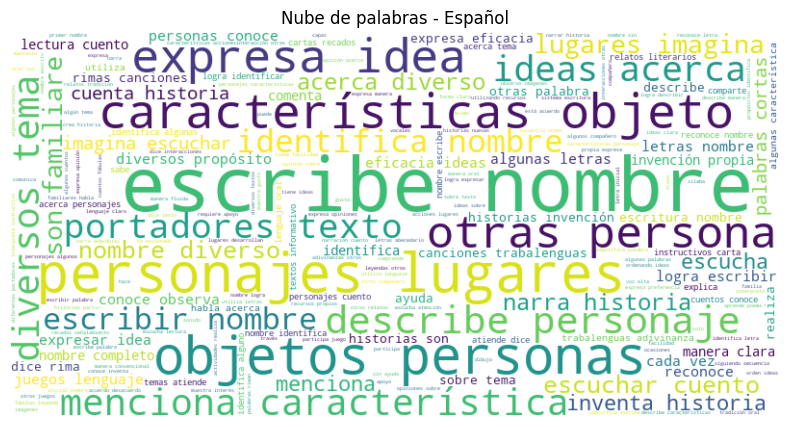

In [16]:
#Generar nube de palabras de Español
wc_espanol = WordCloud(width=800, height=400, background_color="white").generate(TextoE_limpio)

plt.figure(figsize=(10,5))
plt.imshow(wc_espanol, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras - Español")
plt.show()

In [17]:
# #Generar nube de palabras de Matemáticas
# wc_matematicas = WordCloud(width=800, height=400, background_color="white").generate(TextoM_limpio)

# plt.figure(figsize=(10,5))
# plt.imshow(wc_matematicas, interpolation="bilinear")
# plt.axis("off")
# plt.title("Nube de palabras - Matemáticas")
# plt.show()